# Week 9 / 10 - Regression Analysis

**Goal:** Apply regression models to predict a continuous target, starting with a Linear Regression baseline, then increasing model flexibility using Polynomial Regression, and finally controlling overfitting using Ridge Regularization. Use validation results to choose the best model and explain the trade-off between underfitting and overfitting.

## A. Setup + Data Preparation

In [4]:
import os
import sys
import platform
import json
import math
import random

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Pandas:', pd.__version__)

Python: 3.13.1
Platform: Windows-10-10.0.19045-SP0
Pandas: 3.0.1


In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd() / "energy_consumption"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
CONFIGS = PROJECT_ROOT / "configs"

for p in [DATA_RAW, DATA_INTERIM, DATA_PROCESSED, REPORTS, CONFIGS]:
    p.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

SEED = 42

In [10]:
data_raw = pd.read_csv(DATA_RAW / "energy_data_raw.csv")
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB


In [14]:
data_raw.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [18]:
data = data_raw.copy()

data = data.rename(columns = {
    "Building Type": "building_type",
    "Square Footage": "square_footage",
    "Number of Occupants": "number_of_occupants",
    "Appliances Used": "appliances_used",
    "Average Temperature": "average_temperature",
    "Day of Week": "day_of_week",
    "Energy Consumption": "energy_consumption"
})

data["building_type"] = data["building_type"].str.lower().astype("category")
data["day_of_week"] = data["day_of_week"].str.lower().astype("category")

data.to_csv(DATA_PROCESSED / "energy_data_processed.csv", index=False)

print(data.dtypes)

building_type          category
square_footage            int64
number_of_occupants       int64
appliances_used           int64
average_temperature     float64
day_of_week            category
energy_consumption      float64
dtype: object


In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

y = data["energy_consumption"]

X = data.drop(columns=["energy_consumption"])
prep = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(drop='first'), ['building_type', 'day_of_week']),
    ('num', StandardScaler(), ['square_footage', 'number_of_occupants', 'appliances_used', 'average_temperature'])
])
X = prep.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (700, 7) (700,)
Validation set: (150, 7) (150,)
Test set: (150, 7) (150,)


**Chosen regression evaluation criteria:**
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² score

TODO:
Write 1–2 sentences: Why is regression the correct supervised learning setting for this problem?

## B. Linear Regression Baseline

### B1. Initial Model

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

linear_regression_results = {
    "intercept": model.intercept_,
    "coefficients": model.coef_,
    "train_mse": mean_squared_error(y_train, model.predict(X_train)),
    "val_mse": mean_squared_error(y_val, model.predict(X_val)),
    "val_rmse": np.sqrt(mean_squared_error(y_val, model.predict(X_val))),
    "val_mae": mean_absolute_error(y_val, model.predict(X_val)),
    "val_r2": r2_score(y_val, model.predict(X_val))
}

print("---------- Linear Regression Results ----------")
for metric, value in linear_regression_results.items():
    print(f"{metric}: {value}")

---------- Linear Regression Results ----------
intercept: 4205.903085330073
coefficients: [ 500.00042716 -500.00003593  -50.00155034  714.36997865  290.47434894
  281.96256361  -35.68268186]
train_mse: 0.00018503058723712086
val_mse: 0.00018609154447098015
val_rmse: 0.013641537467271795
val_mae: 0.011735886597519615
val_r2: 0.999999999754069


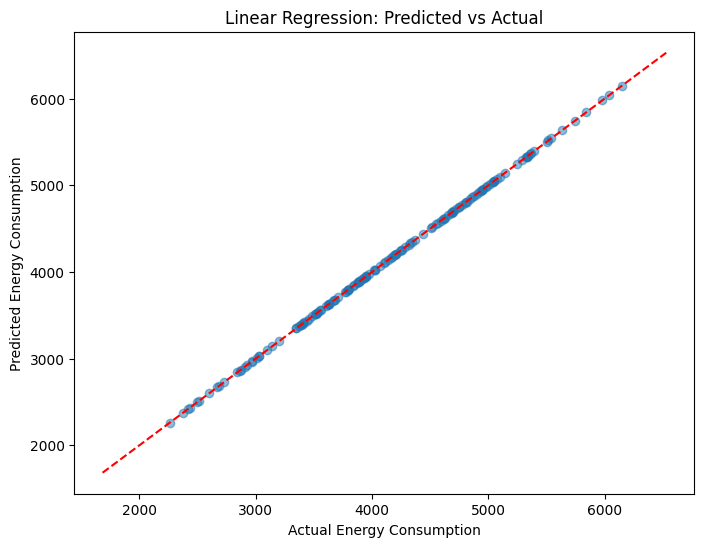

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, model.predict(X_val), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

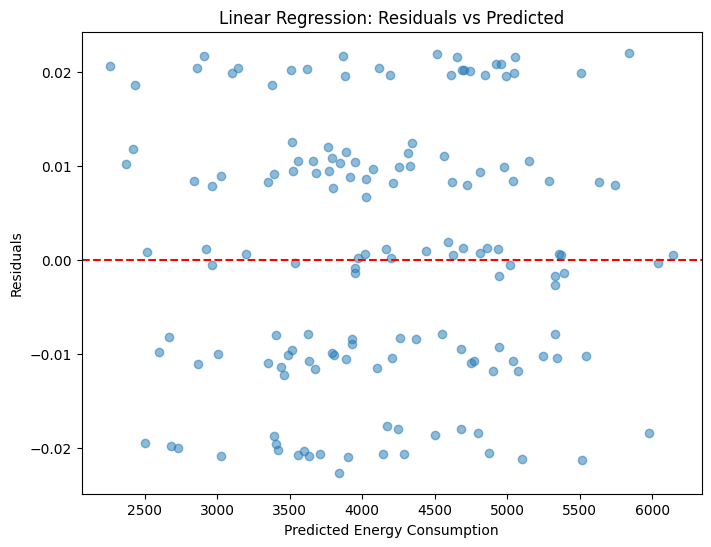

In [30]:
residuals = y_val - model.predict(X_val)
plt.figure(figsize=(8, 6))
plt.scatter(model.predict(X_val), residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Energy Consumption")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residuals vs Predicted")
plt.show()

### B2. Interpreting the Baseline

In [32]:
# identify which features appear to have the strongest influence on the prediction.


Does the linear model seem to fit the data well? What patterns do you notice in the residuals or prediction errors?

## C. Polynomial Regression

### C1. Increasing Flexibility

In [39]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

def report_poly_reg(poly_degree = 2):
    poly_features = PolynomialFeatures(degree=poly_degree)
    model = LinearRegression()
    
    poly_reg = Pipeline([
        ('poly_features', poly_features),
        ('linear_model', model)
    ])

    poly_reg.fit(X_train, y_train)

    poly_reg_results = {
        "poly_degree": poly_degree,
        "train_mse": mean_squared_error(y_train, poly_reg.predict(X_train)),
        "val_mse": mean_squared_error(y_val, poly_reg.predict(X_val)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, poly_reg.predict(X_val))),
        "val_mae": mean_absolute_error(y_val, poly_reg.predict(X_val)),
        "val_r2": r2_score(y_val, poly_reg.predict(X_val))
    }
    
    return poly_reg_results

all_poly_results = []
for poly_degree in [2, 3, 4]:
    results = report_poly_reg(poly_degree)
    print(f"---------- Polynomial Regression (degree = {poly_degree}) Results ----------")
    for metric, value in results.items():
        print(f"{metric}: {value}")
    print()

    all_poly_results.append(results)


---------- Polynomial Regression (degree = 2) Results ----------
poly_degree: 2
train_mse: 0.00018031796675995075
val_mse: 0.00019143624483669005
val_rmse: 0.013836048743651132
val_mae: 0.011871418453538354
val_r2: 0.9999999997470056

---------- Polynomial Regression (degree = 3) Results ----------
poly_degree: 3
train_mse: 0.00016575580909444237
val_mse: 0.00021985162863877693
val_rmse: 0.014827394533051885
val_mae: 0.012800133185901359
val_r2: 0.999999999709453

---------- Polynomial Regression (degree = 4) Results ----------
poly_degree: 4
train_mse: 0.000138416904253245
val_mse: 0.0003051177233644821
val_rmse: 0.0174676192815301
val_mae: 0.01423285772446737
val_r2: 0.9999999995967688



### C2. Model Selection

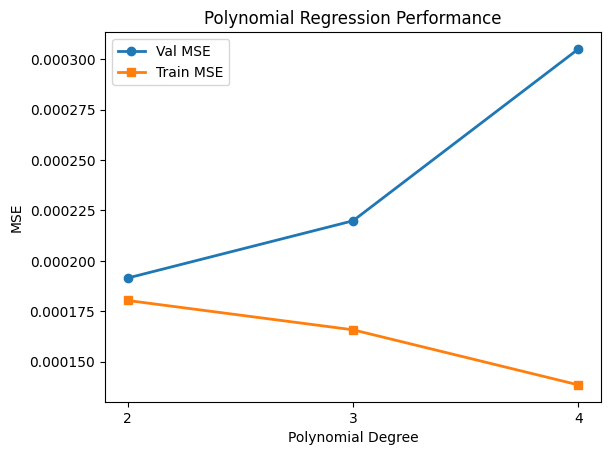

In [48]:
# connect the dots
poly_degrees = [result["poly_degree"] for result in all_poly_results]
train_mses = [result["train_mse"] for result in all_poly_results]
val_mses = [result["val_mse"] for result in all_poly_results]

plt.plot(poly_degrees, val_mses, marker='o', label='Val MSE', linewidth=2)
plt.plot(poly_degrees, train_mses, marker='s', label='Train MSE', linewidth=2)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Polynomial Regression Performance")
plt.legend()
plt.xticks(poly_degrees)
plt.show()

The best polynomial degree value based on validation performance is 2.

**What happened to the training error as model flexibility increased? What happened to the validation error?**

As the model's flexibility increased, the training error decreased a little but the validation error sharply increased.
This suggests overfitting.

**Which degrees appear to underfit, and which appear to overfit?**

None of the tested degrees seem to underfit.<br/>
Choosing 3 degrees seems to overfit a little, while choosing 4 seems to produce a big uptick in overfitting.

### C3. Visualization

In [ ]:
# create visualization comparing the baseline linear fit and the best polynomial fit using lin_reg_results and all_poly_results


## D. Ridge Regression

### D1. Regularization Setup

### D2. Tuning Regularization Strength

### D3. Effect of Regularization

## E. Final Comparison of Regression Models

### E1. Comparison Table

### E2. Analysis of Results